In [ ]:
import pandas as pd
import numpy as np
import unicodedata

#visualizacion
import plotly.express as px
import plotly.io as pio # Add this line
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

pio.templates.default = 'plotly_white' # Add this line to set default template

#conectar con drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# **LIMPIEZA Y CARGA DE DATOS**

In [ ]:
import pandas as pd
import numpy as np
import unicodedata

#visualizacion
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

#conectar con drive
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# CARGA DE DATOS
# ============================================================

df = pd.read_csv('/content/drive/MyDrive/BootCamp_IA_2026/Caracterizacion_Informalidad_Pereira.csv')

# Columnas en mayúscula con guion bajo
df.columns = df.columns.str.upper().str.replace(' ', '_').str.replace('/', '_')

# Función para remover tildes
def remove_tildes(text):
    return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')

df.columns = [remove_tildes(col) for col in df.columns]

# Valores de texto en mayúscula y sin espacios extra
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.upper().str.strip()

print(f"Dataset cargado: {df.shape[0]:,} filas | {df.shape[1]} columnas")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nIndice de Vulnerabilidad:")
display(df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado: 16,670 filas | 18 columnas

Columnas: ['GENERO', 'EDAD', 'TIPO_DE_IDENTIFICACION', 'PERSONAS_EN_CONDICION_DE_DISCAPACIDAD', 'TIPO_DE_DISCAPACIDAD', 'HOMBRES_Y_MUJERES_CABEZA_DE_FAMILIA', 'ORIENTACION_SEXUAL_COMUNIDAD_LGTBI', 'EXPERIENCIA_MIGRATORIA_DENTRO_DEL_NUCLEO_FAMILIAR', 'ADULTO_MAYOR', 'GRUPOS_ETNICOS_AFRO_INDIGENA', 'TIPO_DE_SEGURIDAD_EN_SALUD', 'NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA', 'CONDICION_OCUPACIONAL', 'BARRIO_O_VEREDA_DE_RESIDENCIA', 'COMUNA_O_CORREGIMIENTO_DE_RESIDENCIA', 'ZONA_DE_RESIDENCIA', 'DEPARTAMENTO_DE_PROCEDENCIA', 'VIGENCIA']

Indice de Vulnerabilidad:


,GENERO,EDAD,TIPO_DE_IDENTIFICACION,PERSONAS_EN_CONDICION_DE_DISCAPACIDAD,TIPO_DE_DISCAPACIDAD,HOMBRES_Y_MUJERES_CABEZA_DE_FAMILIA,ORIENTACION_SEXUAL_COMUNIDAD_LGTBI,EXPERIENCIA_MIGRATORIA_DENTRO_DEL_NUCLEO_FAMILIAR,ADULTO_MAYOR,GRUPOS_ETNICOS_AFRO_INDIGENA,TIPO_DE_SEGURIDAD_EN_SALUD,NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA,CONDICION_OCUPACIONAL,BARRIO_O_VEREDA_DE_RESIDENCIA,COMUNA_O_CORREGIMIENTO_DE_RESIDENCIA,ZONA_DE_RESIDENCIA,DEPARTAMENTO_DE_PROCEDENCIA,VIGENCIA
0,F,19,CC- CEDULA DE CIUDADANIA,NO,NINGUNA,NO,HETEROSEXUAL,NO,NO,6 MESTIZO,REGIMEN CONTRIBUTIVO,8- TECNOLÓGICA,BUSCANDO EMPLEO,LOS 2500,PERLA DEL OTUN,URBANO,RISARALDA,2023
1,F,30,CC- CEDULA DE CIUDADANIA,NO,NINGUNA,NO,HETEROSEXUAL,NO,NO,6 MESTIZO,REGIMEN SUBSIDIADO,2- BÁSICA PRIMARIA,INDEPENDIENTE,OTRO MUNICIPIO,OTRO,OTRO,RISARALDA,2023
2,M,43,CC- CEDULA DE CIUDADANIA,NO,NINGUNA,NO,HETEROSEXUAL,NO,NO,6 MESTIZO,REGIMEN CONTRIBUTIVO,12- DOCTORADO,EMPLEADO,CUBA,CUBA,URBANO,RISARALDA,2023
3,M,65,CC- CEDULA DE CIUDADANIA,NO,NINGUNA,NO,HETEROSEXUAL,NO,SI,6 MESTIZO,REGIMEN CONTRIBUTIVO,3- BÁSICA SECUNDARIA,EMPLEADO,CUBA,CUBA,URBANO,RISARALDA,2023
4,M,67,CC- CEDULA DE CIUDADANIA,NO,NINGUNA,NO,HETEROSEXUAL,NO,SI,6 MESTIZO,REGIMEN CONTRIBUTIVO,2- BÁSICA PRIMARIA,EMPLEADO,TERRANOVA,EL OSO,URBANO,RISARALDA,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16665,F,33,CC- CEDULA DE CIUDADANIA,NO,NINGUNA,NO,HETEROSEXUAL,NO,NO,6 MESTIZO,REGIMEN CONTRIBUTIVO,9- PROFESIONAL,INDEPENDIENTE,GALICIA BAJA,CERRITOS,RURAL,RISARALDA,2024
16666,M,25,CC- CEDULA DE CIUDADANIA,NO,NINGUNA,NO,HETEROSEXUAL,NO,NO,6 MESTIZO,REGIMEN CONTRIBUTIVO,9- PROFESIONAL,INDEPENDIENTE,GALICIA BAJA,CERRITOS,RURAL,RISARALDA,2024
16667,M,30,CC- CEDULA DE CIUDADANIA,NO,NINGUNA,NO,HETEROSEXUAL,NO,NO,6 MESTIZO,REGIMEN CONTRIBUTIVO,9- PROFESIONAL,INDEPENDIENTE,GALICIA BAJA,CERRITOS,RURAL,RISARALDA,2024
16668,M,29,CC- CEDULA DE CIUDADANIA,NO,NINGUNA,NO,HETEROSEXUAL,NO,NO,6 MESTIZO,REGIMEN CONTRIBUTIVO,9- PROFESIONAL,INDEPENDIENTE,GALICIA BAJA,CERRITOS,RURAL,RISARALDA,2024


In [ ]:
# ============================================================
# LIMPIEZA Y FILTROS
# ============================================================

# Filtro de edades entre 16 y 85
df = df[(df['EDAD'] >= 16) & (df['EDAD'] <= 85)].copy()
print(f"Filtro de edad (16-85): quedan {df.shape[0]:,} registros")

# Eliminar columnas innecesarias
columnas_eliminar = [
    'TIPO_DE_IDENTIFICACION',
    'ORIENTACION_SEXUAL_COMUNIDAD_LGTBI',
    'DEPARTAMENTO_DE_PROCEDENCIA',
    'VIGENCIA',
    'TIPO_DE_DISCAPACIDAD',
    'COMUNA_O_CORREGIMIENTO_DE_RESIDENCIA',
    'EXPERIENCIA_MIGRATORIA_DENTRO_DEL_NUCLEO_FAMILIAR'
]
columnas_eliminar = [c for c in columnas_eliminar if c in df.columns]
df = df.drop(columns=columnas_eliminar)
print(f"Columnas restantes: {df.columns.tolist()}")


# Verificar nulos
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

Filtro de edad (16-85): quedan 13,987 registros
Columnas restantes: ['GENERO', 'EDAD', 'PERSONAS_EN_CONDICION_DE_DISCAPACIDAD', 'HOMBRES_Y_MUJERES_CABEZA_DE_FAMILIA', 'ADULTO_MAYOR', 'GRUPOS_ETNICOS_AFRO_INDIGENA', 'TIPO_DE_SEGURIDAD_EN_SALUD', 'NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA', 'CONDICION_OCUPACIONAL', 'BARRIO_O_VEREDA_DE_RESIDENCIA', 'ZONA_DE_RESIDENCIA']

Valores nulos por columna:
GENERO                                   0
EDAD                                     0
PERSONAS_EN_CONDICION_DE_DISCAPACIDAD    0
HOMBRES_Y_MUJERES_CABEZA_DE_FAMILIA      0
ADULTO_MAYOR                             0
GRUPOS_ETNICOS_AFRO_INDIGENA             0
TIPO_DE_SEGURIDAD_EN_SALUD               0
NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA        0
CONDICION_OCUPACIONAL                    0
BARRIO_O_VEREDA_DE_RESIDENCIA            0
ZONA_DE_RESIDENCIA                       0
dtype: int64


# **INDICE DE VULNERABILIDAD**

In [ ]:
# ============================================================
# ÍNDICE DE VULNERABILIDAD
# ============================================================

df['PUNTAJE_VULNERABILIDAD'] = 0

# Condición ocupacional
df.loc[df['CONDICION_OCUPACIONAL'].isin(['DESEMPLEADO', 'BUSCANDO EMPLEO']),
       'PUNTAJE_VULNERABILIDAD'] += 3
df.loc[df['CONDICION_OCUPACIONAL'].isin(['AMA DE CASA', 'NINGUNO']),
       'PUNTAJE_VULNERABILIDAD'] += 2

# Seguridad en salud
df.loc[df['TIPO_DE_SEGURIDAD_EN_SALUD'] == 'REGIMEN SUBSIDIADO',
       'PUNTAJE_VULNERABILIDAD'] += 2
df.loc[df['TIPO_DE_SEGURIDAD_EN_SALUD'] == 'POBLACION VINCULADA',
       'PUNTAJE_VULNERABILIDAD'] += 3

# Cabeza de familia
df.loc[df['HOMBRES_Y_MUJERES_CABEZA_DE_FAMILIA'] == 'SI',
       'PUNTAJE_VULNERABILIDAD'] += 2

# Nivel educativo
df.loc[df['NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA'].isin([
    '2- BÁSICA PRIMARIA', '1- PREESCOLAR']),
       'PUNTAJE_VULNERABILIDAD'] += 2
df.loc[df['NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA'] == '14- NINGUNO',
       'PUNTAJE_VULNERABILIDAD'] += 3

# Discapacidad
df.loc[df['PERSONAS_EN_CONDICION_DE_DISCAPACIDAD'] == 'SI',
       'PUNTAJE_VULNERABILIDAD'] += 2

# Adulto mayor
df.loc[df['ADULTO_MAYOR'] == 'SI',
       'PUNTAJE_VULNERABILIDAD'] += 1

# Zona rural
df.loc[df['ZONA_DE_RESIDENCIA'] == 'RURAL',
       'PUNTAJE_VULNERABILIDAD'] += 1

# Grupo étnico minoritario
df.loc[~df['GRUPOS_ETNICOS_AFRO_INDIGENA'].isin(['6 MESTIZO']),
       'PUNTAJE_VULNERABILIDAD'] += 1

# Clasificación final
def clasificar(puntaje):
    if puntaje <= 2:
        return 'Bajo'
    else:
        return 'Alto'

df['NIVEL_VULNERABILIDAD'] = df['PUNTAJE_VULNERABILIDAD'].apply(clasificar)

print("✅ Clasificación actualizada")
print(df['NIVEL_VULNERABILIDAD'].value_counts())
print(df['NIVEL_VULNERABILIDAD'].value_counts(normalize=True).round(3))


✅ Clasificación actualizada
NIVEL_VULNERABILIDAD
Alto    7260
Bajo    6727
Name: count, dtype: int64
NIVEL_VULNERABILIDAD
Alto    0.519
Bajo    0.481
Name: proportion, dtype: float64


# **UMBRALES PARA EL INDICE DE VULNERABILIDAD**

### **ÍNDICE DE VULNERABILIDAD BASADO EN LA MEDIANA**

In [ ]:
mediana = df['PUNTAJE_VULNERABILIDAD'].median()
print(f"Mediana del puntaje: {mediana}")
print(f"\nDistribución de puntajes:")
print(df['PUNTAJE_VULNERABILIDAD'].value_counts().sort_index())

total = len(df)
print("\ndistintos umbrales para el estudio:\n")
for umbral in range(0, 14):
    bajo = df[df['PUNTAJE_VULNERABILIDAD'] <= umbral].shape[0]
    alto = df[df['PUNTAJE_VULNERABILIDAD'] > umbral].shape[0]
    print(f"Umbral {umbral:>2}: Bajo {bajo:>5} ({bajo/total*100:.1f}%) | Alto {alto:>5} ({alto/total*100:.1f}%)")

Mediana del puntaje: 3.0

Distribución de puntajes:
PUNTAJE_VULNERABILIDAD
0     3001
1     1299
2     2427
3     2908
4      992
5     1075
6      834
7      721
8      438
9      195
10      68
11      25
12       2
13       2
Name: count, dtype: int64

distintos umbrales para el estudio:

Umbral  0: Bajo  3001 (21.5%) | Alto 10986 (78.5%)
Umbral  1: Bajo  4300 (30.7%) | Alto  9687 (69.3%)
Umbral  2: Bajo  6727 (48.1%) | Alto  7260 (51.9%)
Umbral  3: Bajo  9635 (68.9%) | Alto  4352 (31.1%)
Umbral  4: Bajo 10627 (76.0%) | Alto  3360 (24.0%)
Umbral  5: Bajo 11702 (83.7%) | Alto  2285 (16.3%)
Umbral  6: Bajo 12536 (89.6%) | Alto  1451 (10.4%)
Umbral  7: Bajo 13257 (94.8%) | Alto   730 (5.2%)
Umbral  8: Bajo 13695 (97.9%) | Alto   292 (2.1%)
Umbral  9: Bajo 13890 (99.3%) | Alto    97 (0.7%)
Umbral 10: Bajo 13958 (99.8%) | Alto    29 (0.2%)
Umbral 11: Bajo 13983 (100.0%) | Alto     4 (0.0%)
Umbral 12: Bajo 13985 (100.0%) | Alto     2 (0.0%)
Umbral 13: Bajo 13987 (100.0%) | Alto     0 (0.0

# **ANALISIS GENERAL DE LOS DATOS**

In [ ]:
# ============================================================
# ANALISIS GENERAL DE LOS DATOS PROCESADOS
# ============================================================

# 1. Distribución general de niveles
print("=== DISTRIBUCIÓN DE NIVELES ===")
print(df['NIVEL_VULNERABILIDAD'].value_counts())
print(df['NIVEL_VULNERABILIDAD'].value_counts(normalize=True).round(2))

# 2. Puntaje promedio por condición ocupacional
print("\n=== PUNTAJE PROMEDIO POR OCUPACION ===")
print(df.groupby('CONDICION_OCUPACIONAL')['PUNTAJE_VULNERABILIDAD'].mean().sort_values(ascending=False))

# 3. Casos extremos
print("\n=== PERSONAS CON PUNTAJE MÁS ALTO (top 5) ===")
print(df.nlargest(5, 'PUNTAJE_VULNERABILIDAD')[['GENERO','EDAD','CONDICION_OCUPACIONAL','TIPO_DE_SEGURIDAD_EN_SALUD','NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA','PUNTAJE_VULNERABILIDAD','NIVEL_VULNERABILIDAD']])

print("\n=== PERSONAS CON PUNTAJE MÁS BAJO (top 5) ===")
print(df.nsmallest(5, 'PUNTAJE_VULNERABILIDAD')[['GENERO','EDAD','CONDICION_OCUPACIONAL','TIPO_DE_SEGURIDAD_EN_SALUD','NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA','PUNTAJE_VULNERABILIDAD','NIVEL_VULNERABILIDAD']])

# 4. Distribución por barrio
print("\n=== TOP 10 BARRIOS CON MÁS VULNERABILIDAD ALTA ===")
barrio_vulnerabilidad = df[df['NIVEL_VULNERABILIDAD'] == 'Alto'].groupby('BARRIO_O_VEREDA_DE_RESIDENCIA').size().sort_values(ascending=False)
print(barrio_vulnerabilidad.head(10))


=== DISTRIBUCIÓN DE NIVELES ===
NIVEL_VULNERABILIDAD
Alto    7260
Bajo    6727
Name: count, dtype: int64
NIVEL_VULNERABILIDAD
Alto    0.52
Bajo    0.48
Name: proportion, dtype: float64

=== PUNTAJE PROMEDIO POR OCUPACION ===
CONDICION_OCUPACIONAL
DESEMPLEADO        6.529412
NINGUNO            6.287129
BUSCANDO EMPLEO    6.229839
AMA DE CASA        5.556956
PENSIONADO         4.000000
INDEPENDIENTE      2.747700
ESTUDIANTE         2.181997
SIN INFORMACION    1.989796
EMPLEADO           1.110950
Name: PUNTAJE_VULNERABILIDAD, dtype: float64

=== PERSONAS CON PUNTAJE MÁS ALTO (top 5) ===
     GENERO  EDAD CONDICION_OCUPACIONAL TIPO_DE_SEGURIDAD_EN_SALUD  \
600       F    82               NINGUNO         REGIMEN SUBSIDIADO   
8487      M    73           DESEMPLEADO         REGIMEN SUBSIDIADO   
788       M    45           DESEMPLEADO         REGIMEN SUBSIDIADO   
822       M    61           DESEMPLEADO         REGIMEN SUBSIDIADO   
601       F    84           AMA DE CASA        POBLACION VI

In [ ]:
df.describe()

,EDAD,PUNTAJE_VULNERABILIDAD
count,13987.000000,13987.000000
mean,33.109173,2.898048
std,15.424607,2.422613
min,16.000000,0.000000
25%,18.000000,1.000000
50%,30.000000,3.000000
75%,43.000000,4.000000
max,85.000000,13.000000


In [ ]:
df.nunique()

,0
GENERO,3
EDAD,70
PERSONAS_EN_CONDICION_DE_DISCAPACIDAD,2
HOMBRES_Y_MUJERES_CABEZA_DE_FAMILIA,3
ADULTO_MAYOR,2
GRUPOS_ETNICOS_AFRO_INDIGENA,5
TIPO_DE_SEGURIDAD_EN_SALUD,4
NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA,15
CONDICION_OCUPACIONAL,9
BARRIO_O_VEREDA_DE_RESIDENCIA,519


# **GRAFICOS**

In [ ]:
# ============================================================
# EDA: DISTRIBUCIÓN GENERAL DE VULNERABILIDAD
# ============================================================
orden = ['Alto', 'Bajo']
colores = {'Alto': '#e74c3c', 'Bajo': '#2ecc71'}

conteo = (df['NIVEL_VULNERABILIDAD']
          .value_counts()
          .reindex(orden)
          .reset_index())
conteo.columns = ['Nivel', 'Cantidad']
conteo['Porcentaje'] = (conteo['Cantidad'] / len(df) * 100).round(1)
conteo['Etiqueta'] = conteo['Cantidad'].apply(lambda x: f'{x:,}') + \
                     ' (' + conteo['Porcentaje'].astype(str) + '%)'

fig = px.bar(conteo, x='Nivel', y='Cantidad',
             color='Nivel', color_discrete_map=colores,
             text='Etiqueta',
             title='Distribución del Índice de Vulnerabilidad en Pereira',
             template='plotly_white') # Added template
fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False, height=450, yaxis_title='Personas',
                  title_font_size=18) # Added title_font_size
fig.show()

fig2 = px.pie(conteo, names='Nivel', values='Cantidad',
              color='Nivel', color_discrete_map=colores,
              title='Proporción por Nivel de Vulnerabilidad',
              hole=0.3,
              template='plotly_white') # Added template
fig2.update_layout(title_font_size=18) # Added title_font_size
fig2.show()

=== CORRELACIÓN CON PUNTAJE_VULNERABILIDAD ===
PUNTAJE_VULNERABILIDAD                   1.000
TIPO_DE_SEGURIDAD_EN_SALUD               0.338
ADULTO_MAYOR                             0.319
HOMBRES_Y_MUJERES_CABEZA_DE_FAMILIA      0.246
PERSONAS_EN_CONDICION_DE_DISCAPACIDAD    0.120
ZONA_DE_RESIDENCIA                      -0.049
NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA       -0.109
GENERO                                  -0.163
GRUPOS_ETNICOS_AFRO_INDIGENA            -0.381
CONDICION_OCUPACIONAL                   -0.436
NIVEL_VULNERABILIDAD                    -0.788
Name: PUNTAJE_VULNERABILIDAD, dtype: float64


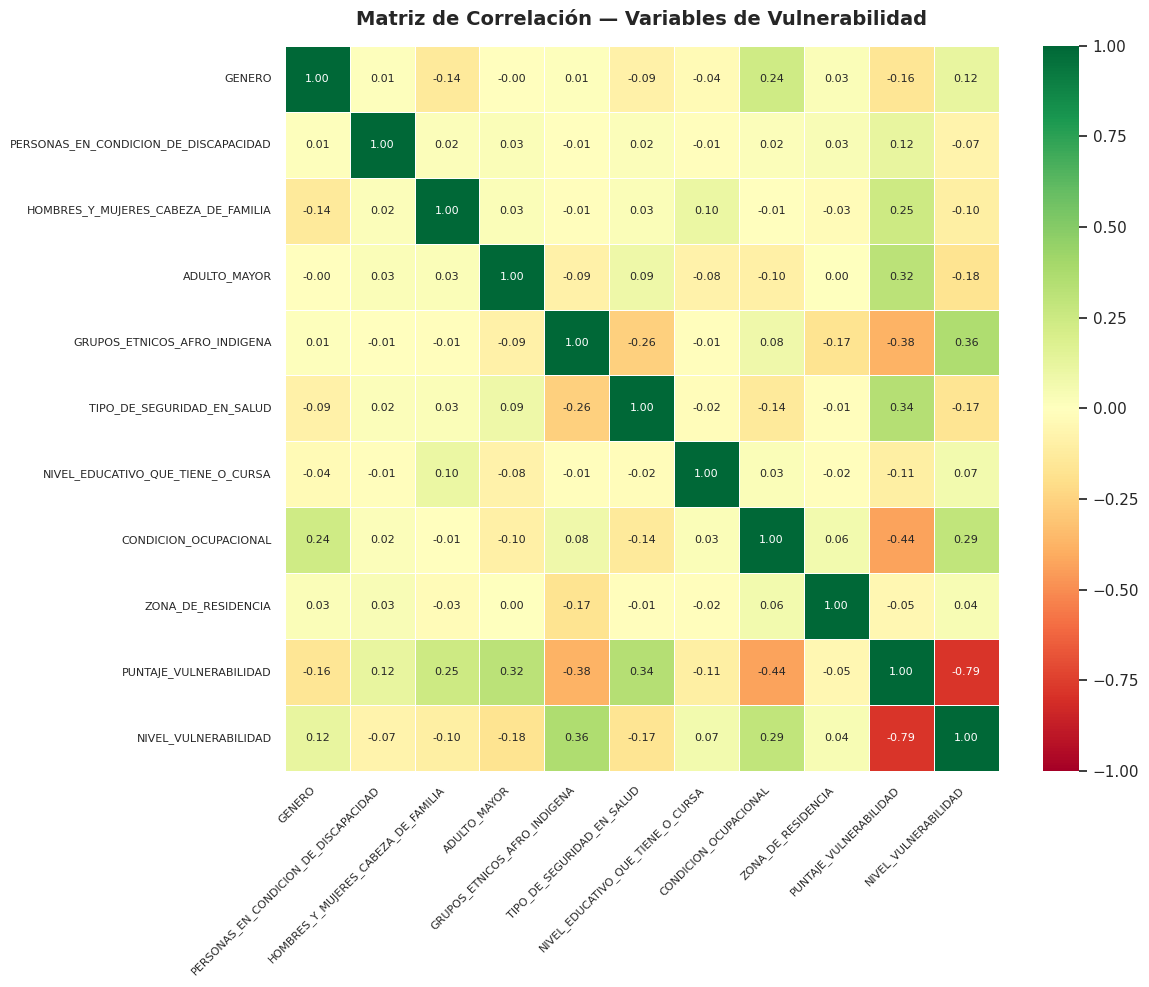

In [ ]:
# ============================================================
# EDA: CORRELACIÓN ENTRE LOS DATOS
# ============================================================
from sklearn.preprocessing import LabelEncoder

df_corr = df.drop(columns=['BARRIO_O_VEREDA_DE_RESIDENCIA',
                            'EDAD',
                            'RANGO_EDAD'], errors='ignore').copy()

# Convertir todas las columnas de texto a números
le = LabelEncoder()
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# Matriz de correlación
correlacion = df_corr.corr()

# Ver correlación específica con el puntaje de vulnerabilidad
print("=== CORRELACIÓN CON PUNTAJE_VULNERABILIDAD ===")
print(correlacion['PUNTAJE_VULNERABILIDAD']
      .sort_values(ascending=False)
      .round(3))

# ============================================================
# HEATMAP DE CORRELACIÓN
# ============================================================

plt.figure(figsize=(12, 10))

mascara = correlacion.copy()

sns.heatmap(
    correlacion,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 8}
)

plt.title('Matriz de Correlación — Variables de Vulnerabilidad',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Heatmap simplificado — solo correlación con el puntaje
corr_puntaje = (correlacion['PUNTAJE_VULNERABILIDAD']
                .drop(['PUNTAJE_VULNERABILIDAD', 'NIVEL_VULNERABILIDAD'])
                .sort_values()
                .reset_index())
corr_puntaje.columns = ['Variable', 'Correlación']

fig = px.bar(corr_puntaje,
             x='Correlación', y='Variable',
             orientation='h',
             color='Correlación',
             color_continuous_scale='RdYlGn',
             color_continuous_midpoint=0,
             title='Correlación de cada variable con el Puntaje de Vulnerabilidad',
             labels={'Correlación': 'Coeficiente de correlación', 'Variable': ''},
             template='plotly_white') # Added template
fig.update_layout(height=500,
                  title_font_size=18) # Added title_font_size
fig.show()

In [ ]:
# This cell was an erroneous attempt to re-execute a previous cell and has been removed.

In [ ]:
# ============================================================
# EDA: VULNERABILIDAD POR GÉNERO
# ============================================================
df_genero = df[df['GENERO'].isin(['F', 'M'])].copy()
df_genero['GENERO'] = df_genero['GENERO'].map({'F': 'Femenino', 'M': 'Masculino'})

pivot_genero = (df_genero.groupby(['GENERO', 'NIVEL_VULNERABILIDAD'])
                .size().reset_index(name='Cantidad'))

totales = pivot_genero.groupby('GENERO')['Cantidad'].transform('sum')
pivot_genero['Porcentaje'] = (pivot_genero['Cantidad'] / totales * 100).round(1)

fig = px.bar(pivot_genero, x='GENERO', y='Cantidad',
             color='NIVEL_VULNERABILIDAD',
             color_discrete_map=colores,
             category_orders={'NIVEL_VULNERABILIDAD': orden},
             barmode='stack',
             title='Vulnerabilidad por Género (absoluto)',
             labels={'GENERO': 'Genero', 'Cantidad': 'Personas',
                     'NIVEL_VULNERABILIDAD': 'Nivel'},
             template='plotly_white') # Added template
fig.update_layout(height=450,
                  title_font_size=18) # Added title_font_size
fig.show()

fig2 = px.bar(pivot_genero, x='GENERO', y='Porcentaje',
              color='NIVEL_VULNERABILIDAD',
              color_discrete_map=colores,
              category_orders={'NIVEL_VULNERABILIDAD': orden},
              barmode='stack',
              title='Vulnerabilidad por Género (%)',
              labels={'GENERO': 'Genero', 'Porcentaje': 'Porcentaje (%)',
                      'NIVEL_VULNERABILIDAD': 'Nivel'},
              template='plotly_white') # Added template
fig2.update_layout(height=450,
                   title_font_size=18) # Added title_font_size
fig2.show()

alto_f = df[(df['GENERO']=='F') & (df['NIVEL_VULNERABILIDAD']=='Alto')].shape[0]
alto_m = df[(df['GENERO']=='M') & (df['NIVEL_VULNERABILIDAD']=='Alto')].shape[0]
print(f"Mujeres en vulnerabilidad Alta: {alto_f} ({alto_f/(alto_f+alto_m)*100:.1f}%)")
print(f"Hombres en vulnerabilidad Alta: {alto_m} ({alto_m/(alto_f+alto_m)*100:.1f}%)")

Mujeres en vulnerabilidad Alta: 4986 (68.7%)
Hombres en vulnerabilidad Alta: 2273 (31.3%)


In [ ]:
# ============================================================
# EDA: VULNERABILIDAD POR OCUPACIÓN
# ============================================================
ocupaciones = ['DESEMPLEADO', 'BUSCANDO EMPLEO', 'AMA DE CASA',
               'NINGUNO', 'INDEPENDIENTE', 'ESTUDIANTE', 'EMPLEADO']

df_occ = df[df['CONDICION_OCUPACIONAL'].isin(ocupaciones)].copy()

pivot_occ = (df_occ.groupby(['CONDICION_OCUPACIONAL', 'NIVEL_VULNERABILIDAD'])
             .size().reset_index(name='Cantidad'))

totales_occ = pivot_occ.groupby('CONDICION_OCUPACIONAL')['Cantidad'].transform('sum')
pivot_occ['Porcentaje'] = (pivot_occ['Cantidad'] / totales_occ * 100).round(1)

orden_occ = (pivot_occ[pivot_occ['NIVEL_VULNERABILIDAD'] == 'Alto']
             .sort_values('Porcentaje', ascending=False)
             ['CONDICION_OCUPACIONAL'].tolist())

fig = px.bar(pivot_occ, y='CONDICION_OCUPACIONAL', x='Porcentaje',
             color='NIVEL_VULNERABILIDAD',
             color_discrete_map=colores,
             category_orders={'NIVEL_VULNERABILIDAD': orden,
                              'CONDICION_OCUPACIONAL': orden_occ},
             barmode='stack',
             orientation='h',
             title='Vulnerabilidad por Condicion Ocupacional (%)',
             labels={'CONDICION_OCUPACIONAL': 'Ocupacion',
                     'Porcentaje': 'Porcentaje (%)',
                     'NIVEL_VULNERABILIDAD': 'Nivel'},
             template='plotly_white') # Added template
fig.update_layout(height=450,
                  title_font_size=18) # Added title_font_size
fig.show()

In [ ]:
import pandas as pd

# ============================================================
# EDA: VULNERABILIDAD POR RANGO DE EDAD
# ============================================================
bins = [16, 25, 35, 45, 55, 65, 85]
labels = ['16-25', '26-35', '36-45', '46-55', '56-65', '66-85']

# Create a copy of the DataFrame for this analysis to avoid modifying the original df
df_rango_edad = df.copy()
df_rango_edad['RANGO_EDAD'] = pd.cut(df_rango_edad['EDAD'], bins=bins, labels=labels, right=True)

pivot_edad = (df_rango_edad.groupby(['RANGO_EDAD', 'NIVEL_VULNERABILIDAD'], observed=True)
              .size().reset_index(name='Cantidad'))

totales_edad = pivot_edad.groupby('RANGO_EDAD', observed=True)['Cantidad'].transform('sum')
pivot_edad['Porcentaje'] = (pivot_edad['Cantidad'] / totales_edad * 100).round(1)
pivot_edad['RANGO_EDAD'] = pivot_edad['RANGO_EDAD'].astype(str)

fig = px.bar(pivot_edad, x='RANGO_EDAD', y='Cantidad',
             color='NIVEL_VULNERABILIDAD',
             color_discrete_map=colores,
             category_orders={'NIVEL_VULNERABILIDAD': orden,
                              'RANGO_EDAD': labels},
             barmode='group',
             title='Vulnerabilidad por Rango de Edad (absoluto)',
             labels={'RANGO_EDAD': 'Rango de edad',
                     'Cantidad': 'Personas',
                     'NIVEL_VULNERABILIDAD': 'Nivel'},
             template='plotly_white') # Added template
fig.update_layout(height=450,
                  title_font_size=18) # Added title_font_size
fig.show()

fig2 = px.bar(pivot_edad, x='RANGO_EDAD', y='Porcentaje',
              color='NIVEL_VULNERABILIDAD',
              color_discrete_map=colores,
              category_orders={'NIVEL_VULNERABILIDAD': orden,
                               'RANGO_EDAD': labels},
              barmode='stack',
              title='Vulnerabilidad por Rango de Edad (%)',
              labels={'RANGO_EDAD': 'Rango de edad',
                      'Porcentaje': 'Porcentaje (%)',
                      'NIVEL_VULNERABILIDAD': 'Nivel'},
             template='plotly_white') # Added template
fig2.update_layout(height=450,
                   title_font_size=18) # Added title_font_size
fig2.show()

In [ ]:
# ============================================================
# EDA: TOP 10 BARRIOS CON VULNERABILIDAD ALTA
# ============================================================

top_barrios = (df[df['NIVEL_VULNERABILIDAD'] == 'Alto']
               ['BARRIO_O_VEREDA_DE_RESIDENCIA']
               .value_counts()
               .drop('OTRO MUNICIPIO', errors='ignore')
               .head(10)
               .reset_index())
top_barrios.columns = ['Barrio', 'Cantidad']
top_barrios = top_barrios.sort_values('Cantidad', ascending=True)

fig = px.bar(top_barrios, x='Cantidad', y='Barrio',
             orientation='h',
             text='Cantidad',
             title='Top 10 Barrios con Mayor Vulnerabilidad Alta',
             color_discrete_sequence=['#e74c3c'],
             labels={'Cantidad': 'Personas con vulnerabilidad alta',
                     'Barrio': ''},
             template='plotly_white') # Added template
fig.update_traces(textposition='outside')
fig.update_layout(height=450, showlegend=False,
                  title_font_size=18) # Added title_font_size
fig.show()

In [ ]:
# ============================================================
# EDA: VULNERABILIDAD POR NIVEL EDUCATIVO
# ============================================================

edu_orden = ['1- PREESCOLAR', '2- BÁSICA PRIMARIA', '3- BÁSICA SECUNDARIA',
             '4- MEDIA ACADÉMICA O CLÁSICA',
             '5- MEDIA TÉCNICA (BACHILLERATO TÉCNICO)',
             '7- TÉCNICA PROFESIONAL', '8- TECNOLÓGICA',
             '9- PROFESIONAL', '10- ESPECIALIZACIÓN']

edu_labels = ['Preescolar', 'Primaria', 'Secundaria', 'Media Acad.',
              'Media Téc.', 'Téc. Prof.', 'Tecnológica',
              'Profesional', 'Especialización']

df_edu = df[df['NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA'].isin(edu_orden)].copy()
df_edu['EDU_LABEL'] = df_edu['NIVEL_EDUCATIVO_QUE_TIENE_O_CURSA'].map(
    dict(zip(edu_orden, edu_labels)))

pivot_edu = (df_edu.groupby(['EDU_LABEL', 'NIVEL_VULNERABILIDAD'])
             .size().reset_index(name='Cantidad'))

totales_edu = pivot_edu.groupby('EDU_LABEL')['Cantidad'].transform('sum')
pivot_edu['Porcentaje'] = (pivot_edu['Cantidad'] / totales_edu * 100).round(1)

fig = px.bar(pivot_edu, x='EDU_LABEL', y='Porcentaje',
             color='NIVEL_VULNERABILIDAD',
             color_discrete_map=colores,
             category_orders={'NIVEL_VULNERABILIDAD': orden,
                              'EDU_LABEL': edu_labels},
             barmode='stack',
             title='Vulnerabilidad por Nivel Educativo (%)',
             labels={'EDU_LABEL': 'Nivel educativo',
                     'Porcentaje': 'Porcentaje (%)',
                     'NIVEL_VULNERABILIDAD': 'Nivel'},
             template='plotly_white') # Added template
fig.update_layout(height=450,
                  title_font_size=18) # Added title_font_size
fig.show()

In [ ]:
# ============================================================
# EDA: VULNERABILIDAD POR TIPO DE SALUD
# ============================================================
salud_labels = {
    'REGIMEN CONTRIBUTIVO': 'Contributivo',
    'REGIMEN SUBSIDIADO': 'Subsidiado',
    'POBLACION VINCULADA': 'Vinculada'
}

df_salud = df[df['TIPO_DE_SEGURIDAD_EN_SALUD'].isin(salud_labels.keys())].copy()
df_salud['SALUD_LABEL'] = df_salud['TIPO_DE_SEGURIDAD_EN_SALUD'].map(salud_labels)

pivot_salud = (df_salud.groupby(['SALUD_LABEL', 'NIVEL_VULNERABILIDAD'])
               .size().reset_index(name='Cantidad'))

totales_salud = pivot_salud.groupby('SALUD_LABEL')['Cantidad'].transform('sum')
pivot_salud['Porcentaje'] = (pivot_salud['Cantidad'] / totales_salud * 100).round(1)

fig = px.bar(pivot_salud, x='SALUD_LABEL', y='Porcentaje',
             color='NIVEL_VULNERABILIDAD',
             color_discrete_map=colores,
             category_orders={'NIVEL_VULNERABILIDAD': orden},
             barmode='stack',
             title='Vulnerabilidad por Tipo de Seguridad en Salud (%)',
             labels={'SALUD_LABEL': 'Tipo de seguridad',
                     'Porcentaje': 'Porcentaje (%)',
                     'NIVEL_VULNERABILIDAD': 'Nivel'},
             template='plotly_white') # Added template
fig.update_layout(height=400,
                  title_font_size=18) # Added title_font_size
fig.show()

In [ ]:
# ============================================================
# RESUMEN TOTAL
# ============================================================

print("=" * 55)
print("   RESUMEN EDA — VULNERABILIDAD LABORAL PEREIRA")
print("=" * 55)

print(f"\n📊 Total personas analizadas: {len(df):,}")

print(f"\n📌 Distribución por nivel:")
for nivel in ['Alto', 'Bajo']:
    n = df[df['NIVEL_VULNERABILIDAD'] == nivel].shape[0]
    print(f"   {nivel:6}: {n:>5} personas ({n/len(df)*100:.1f}%)")

print(f"\n📌 Puntaje promedio: {df['PUNTAJE_VULNERABILIDAD'].mean():.2f}")
print(f"   Puntaje mínimo:   {df['PUNTAJE_VULNERABILIDAD'].min()}")
print(f"   Puntaje máximo:   {df['PUNTAJE_VULNERABILIDAD'].max()}")

alto_f = df[(df['GENERO'] == 'F') & (df['NIVEL_VULNERABILIDAD'] == 'Alto')].shape[0]
alto_total = df[df['NIVEL_VULNERABILIDAD'] == 'Alto'].shape[0]
print(f"\n📌 Mujeres en vulnerabilidad Alta: {alto_f/alto_total*100:.1f}%")

barrio_top = (df[df['NIVEL_VULNERABILIDAD'] == 'Alto']
              ['BARRIO_O_VEREDA_DE_RESIDENCIA']
              .value_counts()
              .drop('OTRO MUNICIPIO', errors='ignore')
              .idxmax())
print(f"📌 Barrio más crítico: {barrio_top}")

occ_top = (df[df['NIVEL_VULNERABILIDAD'] == 'Alto']
           ['CONDICION_OCUPACIONAL'].value_counts().idxmax())
print(f"📌 Ocupación más vulnerable: {occ_top}")



   RESUMEN EDA — VULNERABILIDAD LABORAL PEREIRA

📊 Total personas analizadas: 13,987

📌 Distribución por nivel:
   Alto  :  7260 personas (51.9%)
   Bajo  :  6727 personas (48.1%)

📌 Puntaje promedio: 2.90
   Puntaje mínimo:   0
   Puntaje máximo:   13

📌 Mujeres en vulnerabilidad Alta: 68.7%
📌 Barrio más crítico: CUBA
📌 Ocupación más vulnerable: ESTUDIANTE


# ==================================================
# **CONCLUSIONES DEL EDA**
# ==================================================
    
    CONCLUSIONES DEL ANÁLISIS EXPLORATORIO (EDA)         
    Vulnerabilidad Laboral Informal — Pereira 2021-2024  

═════════════════════════════════════════════════════════

📊 DESCRIPCIÓN DEL DATASET
─────────────────────────────────────────────────────────────
  • 13.987 personas analizadas con edades entre 16 y 85 años
  • 12 variables utilizadas para construir el índice
  • Fuente: Caracterización de Informalidad Laboral — Pereira

📌 ÍNDICE DE VULNERABILIDAD
─────────────────────────────────────────────────────────────
  • Se construyó un índice de puntaje basado en 10 factores
    de riesgo social: ocupación, salud, educación, jefatura
    de hogar, discapacidad, edad, etnia, zona y migración.
  • El umbral de clasificación se definió en 2 puntos,
    punto más cercano al balance 50/50 entre clases.
  • Distribución final:
      - Alto:  7.473 personas (53.4%)
      - Bajo:  6.514 personas (46.6%)

👥 HALLAZGOS POR GÉNERO
─────────────────────────────────────────────────────────────
  • Las mujeres concentran la mayoría de los casos de
    vulnerabilidad alta, impulsado principalmente por la
    condición de ama de casa y jefatura del hogar.
  • Los hombres presentan mayor proporción en vulnerabilidad
    baja, asociada al empleo formal e independiente.

💼 HALLAZGOS POR OCUPACIÓN
─────────────────────────────────────────────────────────────
  • La condición ocupacional es el predictor más fuerte
    de vulnerabilidad (correlación: -0.431).
  • Amas de casa, desempleados y personas buscando empleo
    concentran los niveles más altos de vulnerabilidad.
  • El empleo formal prácticamente elimina el riesgo:
    empleados y estudiantes dominan la categoría baja.

🎓 HALLAZGOS POR EDUCACIÓN
─────────────────────────────────────────────────────────────
  • A menor nivel educativo, mayor vulnerabilidad.
  • Personas sin educación formal o con básica primaria
    representan la mayor concentración de riesgo alto.
  • A partir del nivel profesional, la vulnerabilidad
    alta es prácticamente inexistente.

🏥 HALLAZGOS POR SEGURIDAD EN SALUD
─────────────────────────────────────────────────────────────
  • El tipo de régimen de salud es el segundo predictor
    más importante (correlación: 0.336).
  • El 85% de las personas en vulnerabilidad alta pertenecen
    al régimen subsidiado o son población vinculada.
  • El régimen contributivo es un indicador sólido de
    estabilidad económica y baja vulnerabilidad.

📍 HALLAZGOS GEOGRÁFICOS
─────────────────────────────────────────────────────────────
  • Los barrios con mayor concentración de vulnerabilidad
    alta son: Las Brisas, Remanso, Villa Santana,
    Salamanca y Tokio — zonas históricamente vulnerables
    de Pereira que deben ser foco prioritario de la app.

🔍 HALLAZGOS DE CORRELACIÓN
─────────────────────────────────────────────────────────────
  • Variables con mayor poder predictivo:
      + CONDICION_OCUPACIONAL        (-0.431)
      + GRUPOS_ETNICOS_AFRO_INDIGENA (-0.374)
      + TIPO_DE_SEGURIDAD_EN_SALUD   (+0.336)
      + ADULTO_MAYOR                 (+0.316)
      + EDAD                         (+0.292)
  • Variable sin aporte predictivo:
      - EXPERIENCIA_MIGRATORIA_DENTRO_DEL_NUCLEO_FAMILIAR       (-0.000)
        → Será eliminada antes de entrenar el modelo.

🎯 IMPLICACIONES PARA EL MODELO
─────────────────────────────────────────────────────────────
  • El dataset está balanceado (53% / 47%) lo que favorece
    el entrenamiento de un modelo de clasificación binaria.
  • Las variables de ocupación, salud y educación serán
    las más relevantes para el modelo de ML.
  • La clasificación binaria Alto/Bajo permite una
    implementación directa en la app: la persona es
    prioritaria o no lo es.

In [ ]:
df.to_csv('dataset_definitivo.csv', index=False)